TRABAJO FINAL DE  LENGUJE  NATURAL


**Autores:** Manuel Alberto Gonzalez Gonzalez - Juan Manuel Hurtado Angulo - William Albertro Reina García

# Chatbot RAG Académico con Ollama + FAISS + Gradio
### Base de conocimiento sobre IA, ML, Ciencia de Datos y Computación en la Nube



Este notebook implementa un chatbot RAG completo que:

- usa **Ollama** como motor LLM local dentro de Colab;
- crea una **base de conocimiento sobre IA, ML, Ciencia de Datos y Computación en la Nube ** a partir de artículos reales de **Wikipedia en español**;
- conserva la estructura **title, summary, document**;
- limita cada documento original a **5000 caracteres**;
- realiza **exploración del corpus** para justificar el `chunk_size` y el `window_size`;
- crea y guarda en disco un **vector store con FAISS**;
- recupera documentos con **top-k**;
- incorpora **historial de conversación resumido** dentro del contexto;
- expone un **chat** con **Gradio**.

---

## Tema sseleccionado es un **Asistente académico de IA y Computación en la Nube**


---

## Arquitectura general
1. **Corpus**: artículos reales de Wikipedia en español filtrados por temática.
2. **Preprocesamiento**: construcción de `title`, `summary` y `document`.
3. **Exploración**: análisis de longitudes para definir chunking.
4. **Chunking**: partición por ventanas solapadas.
5. **Embeddings**: modelo multilingüe.
6. **Índice**: FAISS guardado en disco.
7. **Retriever**: top-k documentos más relevantes.
8. **Generación**: prompt con contexto + historial resumido + pregunta.
9. **Frontend**: chat en Gradio.

In [1]:
# Instalación de dependencias
!pip -q install datasets sentence-transformers faiss-cpu gradio pandas numpy matplotlib tqdm requests ollama wikipedia-api

## 1. Preparación de Ollama

Este notebook usa  el modelo `llama3.2:3b`, este modelo fué recomendado durante la explicación del profesor.


In [2]:
import os
import re
import json
import time
import math
import queue
import faiss
import requests
import threading
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil # Import the shutil module

from tqdm.auto import tqdm
from datasets import load_dataset
from sentence_transformers import SentenceTransformer

IN_COLAB = "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ



MODEL_NAME = "llama3.2:1b"   # Para pruebas en Colab recomiendo 1b primero

def run_cmd(cmd, check=True):
    result = subprocess.run(cmd, capture_output=True, text=True)
    print("CMD:", " ".join(cmd))
    print("STDOUT:\n", result.stdout[:2000])
    print("STDERR:\n", result.stderr[:2000])
    if check and result.returncode != 0:
        raise RuntimeError(f"Comando falló ({result.returncode}): {' '.join(cmd)}")
    return result

def ensure_ollama_server_colab():
    # Try installing zstd first as per error message
    print("Intentando instalar zstd...")
    try:
        run_cmd(["sudo", "apt-get", "update", "-y"], check=False) # Update apt-get first
        run_cmd(["sudo", "apt-get", "install", "zstd", "-y"])
        print("zstd instalado exitosamente.")
    except Exception as e:
        print(f"Advertencia: Falló la instalación de zstd: {e}")

    # 1) Intentar instalación oficial, pero sin abortar de inmediato
    print("Intentando instalar Ollama...")
    install = subprocess.run(
        ["bash", "-lc", "curl -fsSL https://ollama.com/install.sh | sh"],
        capture_output=True,
        text=True
    )

    print("INSTALL STDOUT:\n", install.stdout[:3000])
    print("INSTALL STDERR:\n", install.stderr[:3000])
    print("INSTALL RETCODE:", install.returncode)

    # 2) Buscar el binario aunque el script haya fallado
    ollama_bin = shutil.which("ollama")
    if not ollama_bin:
        for candidate in ["/usr/local/bin/ollama", "/usr/bin/ollama", "/bin/ollama"]:
            if os.path.exists(candidate):
                ollama_bin = candidate
                break

    if not ollama_bin:
        raise RuntimeError(
            "El script no dejó el binario de Ollama disponible. "
            "Revisa el STDERR impreso arriba."
        )

    # 3) Verificar que el binario funcione
    version = subprocess.run([ollama_bin, "--version"], capture_output=True, text=True)
    print("OLLAMA VERSION STDOUT:\n", version.stdout)
    print("OLLAMA VERSION STDERR:\n", version.stderr)
    if version.returncode != 0:
        raise RuntimeError("El binario de Ollama existe, pero no ejecuta correctamente.")

    # 4) Iniciar servidor manualmente, sin systemd
    server_up = False
    try:
        r = requests.get("http://127.0.0.1:11434/api/tags", timeout=3)
        if r.status_code == 200:
            server_up = True
            print("Servidor Ollama ya activo.")
    except Exception:
        pass

    if not server_up:
        print("Iniciando ollama serve...")
        subprocess.Popen(
            [ollama_bin, "serve"],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )

        for _ in range(30):
            try:
                r = requests.get("http://127.0.0.1:11434/api/tags", timeout=3)
                if r.status_code == 200:
                    server_up = True
                    break
            except Exception:
                time.sleep(2)

    if not server_up:
        raise RuntimeError("No se logró iniciar el servidor de Ollama.")

    # 5) Descargar modelo
    print(f"Descargando modelo {MODEL_NAME} ...")
    pull = subprocess.run([ollama_bin, "pull", MODEL_NAME], capture_output=True, text=True)
    print("PULL STDOUT:\n", pull.stdout[:3000])
    print("PULL STDERR:\n", pull.stderr[:3000])

    if pull.returncode != 0:
        raise RuntimeError(f"No se pudo descargar el modelo {MODEL_NAME}.")

    print("Ollama listo.")
    return ollama_bin

ollama_bin = ensure_ollama_server_colab()

Intentando instalar zstd...
CMD: sudo apt-get update -y
STDOUT:
 Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Reading package lists...

STDERR:
 W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' doe

In [17]:
def ollama_generate(prompt, model=MODEL_NAME, temperature=0.2, num_predict=600):
    payload = {
        "model": model,
        "prompt": prompt,
        "stream": False,
        "options": {
            "temperature": temperature,
            "num_predict": num_predict
        }
    }
    response = requests.post("http://127.0.0.1:11434/api/generate", json=payload, timeout=600)
    response.raise_for_status()
    return response.json()["response"]

# Prueba rápida
print(ollama_generate("Responde en una sola frase: ¿Qué es el aprendizaje automático?")[:300])

El aprendizaje automático es un campo de investigación que se enfoca en la creación de sistemas capaces de aprender, recordar y aplicar conocimientos sin la intervención humana.


## 2. Construcción de la base de conocimient

Qquí construiremos una base  con artículos reales de **Wikipedia en español** sobre:

- inteligencia artificial,
- aprendizaje automático,
- redes neuronales,
- procesamiento del lenguaje natural,
- visión por computador,
- ciencia de datos,
- big data,
- computación en la nube,
- bases de datos,
- ciberseguridad,
- programación y temas relacionados.

Cada documento quedará con los campos:
- `title`
- `summary`
- `document`

Además, el documento completo se limitará a **5000 caracteres**, como sugirió el profesor.

In [4]:
TOPIC_KEYWORDS = [
    "inteligencia artificial", "aprendizaje automático", "aprendizaje profundo",
    "red neuronal", "transformer", "bert", "gpt", "procesamiento del lenguaje natural",
    "visión por computador", "ciencia de datos", "minería de datos", "big data",
    "algoritmo", "clasificación", "regresión", "clustering", "machine learning",
    "deep learning", "base de datos", "computación en la nube", "cloud computing",
    "aws", "azure", "google cloud", "docker", "kubernetes", "ciberseguridad",
    "criptografía", "programación", "python", "java", "javascript", "api",
    "sistemas distribuidos", "ingeniería de software", "devops", "microservicios",
    "internet de las cosas", "iot", "robot", "informática", "software", "hardware"
]

TARGET_DOCS = 180
MAX_DOC_CHARS = 5000
MIN_TEXT_CHARS = 1200

def split_sentences(text):
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if s.strip()]

def build_summary(text, max_sentences=2, max_chars=500):
    sents = split_sentences(text)
    if not sents:
        return text[:max_chars]
    summary = " ".join(sents[:max_sentences])
    return summary[:max_chars].strip()

def normalize_text(text):
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def looks_relevant(text, title, keywords):
    joined = f"{title} {text}".lower()
    return any(k.lower() in joined for k in keywords)

def collect_wikipedia_corpus(target_docs=180, max_doc_chars=5000):
    ds = load_dataset("wikimedia/wikipedia", "20231101.es", split="train", streaming=True)

    rows = []
    seen_titles = set()

    for item in ds:
        title = normalize_text(str(item.get("title", "")))
        text = normalize_text(str(item.get("text", "")))

        if not title or not text:
            continue
        if title.lower() in seen_titles:
            continue
        if len(text) < MIN_TEXT_CHARS:
            continue
        if not looks_relevant(text, title, TOPIC_KEYWORDS):
            continue

        summary = build_summary(text, max_sentences=2, max_chars=500)
        document = text[:max_doc_chars]

        rows.append({
            "title": title,
            "summary": summary,
            "document": document,
            "source": f"https://es.wikipedia.org/wiki/{title.replace(' ', '_')}"
        })
        seen_titles.add(title.lower())

        if len(rows) >= target_docs:
            break

    return pd.DataFrame(rows)

df_docs = collect_wikipedia_corpus(target_docs=TARGET_DOCS, max_doc_chars=MAX_DOC_CHARS)
print("Cantidad de documentos recolectados:", len(df_docs))
df_docs.head(10)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Cantidad de documentos recolectados: 180


,title,summary,document,source
0,Andorra,"Andorra, oficialmente Principado de Andorra ()...","Andorra, oficialmente Principado de Andorra ()...",https://es.wikipedia.org/wiki/Andorra
1,Argentina,"Argentina, oficialmente, República Argentina, ...","Argentina, oficialmente, República Argentina, ...",https://es.wikipedia.org/wiki/Argentina
2,Geografía de Andorra,"El Principado de Andorra (nombre local, Princi...","El Principado de Andorra (nombre local, Princi...",https://es.wikipedia.org/wiki/Geografía_de_And...
3,Demografía de Andorra,Andorra cuenta con 81.588 habitantes y una den...,Andorra cuenta con 81.588 habitantes y una den...,https://es.wikipedia.org/wiki/Demografía_de_An...
4,Artes visuales,Las artes visuales engloban las artes plástica...,Las artes visuales engloban las artes plástica...,https://es.wikipedia.org/wiki/Artes_visuales
5,Agricultura,La agricultura (del latín agri ‘campo’ y cultū...,La agricultura (del latín agri ‘campo’ y cultū...,https://es.wikipedia.org/wiki/Agricultura
6,ASCII,ASCII (acrónimo inglés de American Standard Co...,ASCII (acrónimo inglés de American Standard Co...,https://es.wikipedia.org/wiki/ASCII
7,Arquitectura,"La arquitectura (del latín architectūra, archi...","La arquitectura (del latín architectūra, archi...",https://es.wikipedia.org/wiki/Arquitectura
8,Anoeta,Anoeta es una localidad y municipio guipuzcoan...,Anoeta es una localidad y municipio guipuzcoan...,https://es.wikipedia.org/wiki/Anoeta
9,Ana María Matute,"Ana María Matute Ausejo (Barcelona, 26 de juli...","Ana María Matute Ausejo (Barcelona, 26 de juli...",https://es.wikipedia.org/wiki/Ana_María_Matute


## 3. Exploración del corpus

Esta exploración sirve como insumo para justificar el `chunk_size` y el `window_size`.

In [5]:
df_docs["doc_chars"] = df_docs["document"].str.len()
df_docs["doc_words"] = df_docs["document"].str.split().str.len()
df_docs["summary_words"] = df_docs["summary"].str.split().str.len()

display(df_docs[["title", "doc_chars", "doc_words", "summary_words"]].head())

print(df_docs[["doc_chars", "doc_words", "summary_words"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))

,title,doc_chars,doc_words,summary_words
0,Andorra,5000,811,47
1,Argentina,5000,782,32
2,Geografía de Andorra,5000,883,33
3,Demografía de Andorra,5000,811,55
4,Artes visuales,5000,801,77


         doc_chars   doc_words  summary_words
count   180.000000  180.000000     180.000000
mean   4574.716667  728.300000      49.916667
std     994.088355  169.461154      18.178775
min    1209.000000  180.000000      10.000000
25%    5000.000000  742.000000      35.000000
50%    5000.000000  793.500000      49.000000
75%    5000.000000  821.500000      61.250000
90%    5000.000000  840.100000      75.000000
95%    5000.000000  853.000000      79.100000
max    5000.000000  891.000000      90.000000


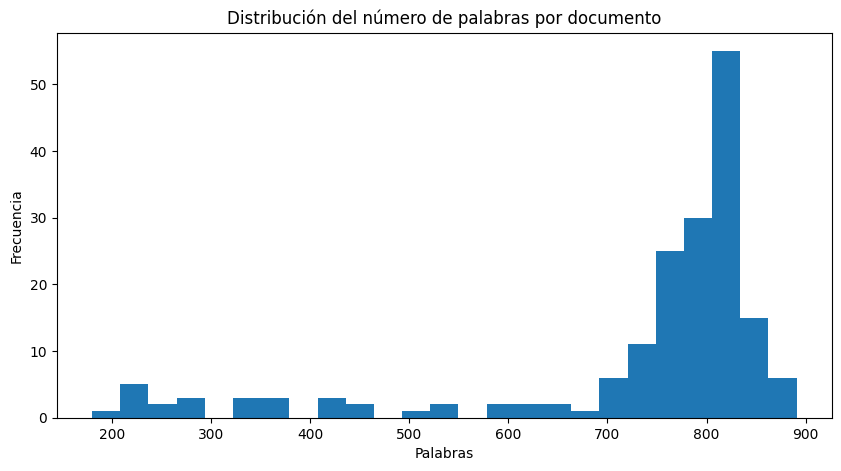

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(df_docs["doc_words"], bins=25)
plt.title("Distribución del número de palabras por documento")
plt.xlabel("Palabras")
plt.ylabel("Frecuencia")
plt.show()

### Decisión de chunking

Después de observar la distribución de longitud:
- los documentos ya fueron limitados a 5000 caracteres;
- aun así, muchos textos siguen siendo demasiado largos para enviarlos completos al contexto;
- por eso se recomienda dividirlos en fragmentos semánticamente manejables.

En esta propuesta usaremos:

- **chunk_size = 180 palabras**
- **window_size / overlap = 40 palabras**

### Justificación
- 180 palabras suelen capturar una idea o subtema completo;
- 40 palabras de solapamiento ayudan a no romper definiciones o relaciones importantes entre párrafos;
- este esquema mejora recuperación y contexto sin inflar innecesariamente el índice.

In [7]:
CHUNK_SIZE = 180
WINDOW_SIZE = 40

print("Chunk size seleccionado:", CHUNK_SIZE)
print("Window size seleccionado:", WINDOW_SIZE)

Chunk size seleccionado: 180
Window size seleccionado: 40


## 4. Construcción de chunks
Cada chunk conservará metadatos del documento original para luego citar fuentes en la respuesta.

In [8]:
def chunk_text_words(text, chunk_size=180, overlap=40):
    words = text.split()
    if len(words) <= chunk_size:
        return [" ".join(words)]

    chunks = []
    step = max(1, chunk_size - overlap)
    for start in range(0, len(words), step):
        chunk = words[start:start + chunk_size]
        if not chunk:
            continue
        chunks.append(" ".join(chunk))
        if start + chunk_size >= len(words):
            break
    return chunks

chunk_rows = []
for idx, row in df_docs.iterrows():
    combined_text = f"Título: {row['title']}\nResumen: {row['summary']}\nDocumento: {row['document']}"
    chunks = chunk_text_words(combined_text, chunk_size=CHUNK_SIZE, overlap=WINDOW_SIZE)

    for j, chunk in enumerate(chunks):
        chunk_rows.append({
            "doc_id": idx,
            "chunk_id": f"{idx}_{j}",
            "title": row["title"],
            "summary": row["summary"],
            "source": row["source"],
            "chunk_text": chunk
        })

df_chunks = pd.DataFrame(chunk_rows)
print("Documentos originales:", len(df_docs))
print("Chunks generados:", len(df_chunks))
df_chunks.head(10)

Documentos originales: 180
Chunks generados: 1041


,doc_id,chunk_id,title,summary,source,chunk_text
0,0,0_0,Andorra,"Andorra, oficialmente Principado de Andorra ()...",https://es.wikipedia.org/wiki/Andorra,"Título: Andorra Resumen: Andorra, oficialmente..."
1,0,0_1,Andorra,"Andorra, oficialmente Principado de Andorra ()...",https://es.wikipedia.org/wiki/Andorra,"y está situado en los Pirineos, entre España y..."
2,0,0_2,Andorra,"Andorra, oficialmente Principado de Andorra ()...",https://es.wikipedia.org/wiki/Andorra,"dictaba que se convocaría al somatén, formado ..."
3,0,0_3,Andorra,"Andorra, oficialmente Principado de Andorra ()...",https://es.wikipedia.org/wiki/Andorra,"como moradores de los Pirineos, puede ser un a..."
4,0,0_4,Andorra,"Andorra, oficialmente Principado de Andorra ()...",https://es.wikipedia.org/wiki/Andorra,los vientos pirenaicos. La etimología popular ...
5,0,0_5,Andorra,"Andorra, oficialmente Principado de Andorra ()...",https://es.wikipedia.org/wiki/Andorra,gules puestas en palo (del Vizcondado de Bearn...
6,1,1_0,Argentina,"Argentina, oficialmente, República Argentina, ...",https://es.wikipedia.org/wiki/Argentina,"Título: Argentina Resumen: Argentina, oficialm..."
7,1,1_1,Argentina,"Argentina, oficialmente, República Argentina, ...",https://es.wikipedia.org/wiki/Argentina,"1991—, la Comunidad de Estados Latinoamericano..."
8,1,1_2,Argentina,"Argentina, oficialmente, República Argentina, ...",https://es.wikipedia.org/wiki/Argentina,los tres estados soberanos latinoamericanos qu...
9,1,1_3,Argentina,"Argentina, oficialmente, República Argentina, ...",https://es.wikipedia.org/wiki/Argentina,"ha ganado —cinco en total—, tres de ellos vinc..."


## 5. Embeddings y vector store

Usaremos un modelo **multilingüe** para que el usuario pueda preguntar en español y recuperar textos relevantes incluso si hay variaciones terminológicas.  
El índice se almacenará en disco para no tener que reconstruirlo cada vez.

In [9]:
EMBEDDING_MODEL_NAME = "intfloat/multilingual-e5-base"
INDEX_DIR = "/content/rag_index_wikipedia_ai"
INDEX_FILE = os.path.join(INDEX_DIR, "faiss.index")
META_FILE = os.path.join(INDEX_DIR, "metadata.parquet")

os.makedirs(INDEX_DIR, exist_ok=True)

embedder = SentenceTransformer(EMBEDDING_MODEL_NAME)
print("Modelo de embeddings cargado:", EMBEDDING_MODEL_NAME)

Modelo de embeddings cargado: intfloat/multilingual-e5-base


In [10]:
def build_embeddings_input(text):
    # e5 recomienda prefijar consultas y pasajes
    return f"passage: {text}"

if os.path.exists(INDEX_FILE) and os.path.exists(META_FILE):
    print("Cargando índice desde disco...")
    index = faiss.read_index(INDEX_FILE)
    df_chunks = pd.read_parquet(META_FILE)
else:
    print("Construyendo índice FAISS desde cero...")
    corpus = [build_embeddings_input(t) for t in df_chunks["chunk_text"].tolist()]
    embeddings = embedder.encode(
        corpus,
        batch_size=32,
        show_progress_bar=True,
        normalize_embeddings=True
    ).astype("float32")

    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings)

    faiss.write_index(index, INDEX_FILE)
    df_chunks.to_parquet(META_FILE, index=False)
    print("Índice guardado en disco.")

print("Tamaño del índice:", index.ntotal)

Cargando índice desde disco...
Tamaño del índice: 1041


## 6. Retriever
El retriever retornará el **top-k** de fragmentos más relevantes.

In [11]:
TOP_K = 5

def retrieve(query, top_k=TOP_K):
    q_emb = embedder.encode(
        [f"query: {query}"],
        normalize_embeddings=True
    ).astype("float32")

    scores, indices = index.search(q_emb, top_k)
    hits = []
    for score, idx in zip(scores[0], indices[0]):
        row = df_chunks.iloc[int(idx)].to_dict()
        row["score"] = float(score)
        hits.append(row)
    return hits

sample_hits = retrieve("¿Qué es el aprendizaje profundo y en qué se diferencia del aprendizaje automático?", top_k=5)
pd.DataFrame(sample_hits)[["title", "score", "source"]]

,title,score,source
0,Algoritmo,0.797626,https://es.wikipedia.org/wiki/Algoritmo
1,Algoritmo,0.788555,https://es.wikipedia.org/wiki/Algoritmo
2,Algoritmo,0.787346,https://es.wikipedia.org/wiki/Algoritmo
3,Algoritmo,0.785267,https://es.wikipedia.org/wiki/Algoritmo
4,Base de datos,0.783820,https://es.wikipedia.org/wiki/Base_de_datos


## 7. Memoria conversacional resumida

El profesor indicó que el historial de conversación debe estar dentro del contexto y que conviene **resumir o condensar** la conversación.  
Aquí implementamos una memoria simple pero útil:

- se guardan los últimos turnos recientes;
- se mantiene un **resumen acumulado** de la conversación;
- cuando crece demasiado, se vuelve a condensar con el LLM.

In [12]:
MAX_RECENT_TURNS = 4
MAX_SUMMARY_CHARS = 1800

def format_recent_turns(turns, max_turns=4):
    recent = turns[-max_turns:]
    if not recent:
        return "Sin historial reciente."
    lines = []
    for user_msg, bot_msg in recent:
        lines.append(f"Usuario: {user_msg}")
        lines.append(f"Asistente: {bot_msg}")
    return "\n".join(lines)

def summarize_history(previous_summary, turns):
    recent_text = format_recent_turns(turns, max_turns=len(turns))
    prompt = f'''
Resume en español la conversación siguiente para conservar contexto útil en un chatbot RAG.
Mantén únicamente:
- intención del usuario,
- conceptos técnicos mencionados,
- preferencias o restricciones importantes,
- preguntas aún no resueltas.

Resumen previo:
{previous_summary}

Conversación nueva:
{recent_text}

Entrega un resumen breve, claro y acumulativo, máximo 180 palabras.
'''.strip()

    summary = ollama_generate(prompt, temperature=0.1, num_predict=220)
    return summary[:MAX_SUMMARY_CHARS].strip()

## 8. Prompt de generación

Aquí combinamos:
- el **resumen del historial**,
- los **turnos recientes**,
- el **contexto recuperado**,
- la **pregunta actual**.

In [13]:
def build_context(hits):
    blocks = []
    for i, h in enumerate(hits, start=1):
        blocks.append(
            f"""[Fuente {i}]
Título: {h['title']}
Resumen: {h['summary']}
Contenido recuperado: {h['chunk_text']}
Enlace: {h['source']}"""
        )
    return "\n\n".join(blocks)

def build_prompt(question, hits, memory_summary="", recent_turns_text=""):
    context = build_context(hits)
    prompt = f'''
Eres un asistente académico especializado en inteligencia artificial, aprendizaje automático,
ciencia de datos, computación en la nube e informática.

Debes responder en español, de forma clara, precisa y bien estructurada.

Reglas:
1. Usa prioritariamente el contexto recuperado.
2. Si la respuesta no está suficientemente soportada por el contexto, dilo con honestidad.
3. No inventes fuentes.
4. Al final agrega una sección llamada "Fuentes consultadas".
5. Si corresponde, menciona diferencias, ventajas, desventajas o ejemplos.
6. Considera el historial resumido para mantener continuidad conversacional.

Historial resumido:
{memory_summary if memory_summary else "Sin historial resumido."}

Turnos recientes:
{recent_turns_text if recent_turns_text else "Sin turnos recientes."}

Contexto recuperado:
{context}

Pregunta del usuario:
{question}

Respuesta:
'''.strip()
    return prompt

## 9. Backend del chatbot
Este bloque encapsula la lógica completa del RAG.

In [14]:
class RAGChatbot:
    def __init__(self, top_k=5):
        self.top_k = top_k
        self.turns = []
        self.memory_summary = ""

    def clear(self):
        self.turns = []
        self.memory_summary = ""

    def ask(self, question):
        recent_turns_text = format_recent_turns(self.turns, max_turns=MAX_RECENT_TURNS)
        hits = retrieve(question, top_k=self.top_k)
        prompt = build_prompt(
            question=question,
            hits=hits,
            memory_summary=self.memory_summary,
            recent_turns_text=recent_turns_text
        )
        answer = ollama_generate(prompt, temperature=0.2, num_predict=700).strip()

        # Guardar turno
        self.turns.append((question, answer))

        # Condensar historial cuando crezca
        if len(self.turns) % 3 == 0:
            self.memory_summary = summarize_history(self.memory_summary, self.turns[-6:])

        sources_md = "\n".join(
            [f"- {i+1}. **{h['title']}** — {h['source']}" for i, h in enumerate(hits)]
        )

        final_answer = f"""{answer}

---
### Fuentes consultadas
{sources_md}
"""
        return final_answer, hits

bot = RAGChatbot(top_k=TOP_K)

## 10. Pruebas rápidas del sistema

In [15]:
test_questions = [
    "¿Qué es la inteligencia artificial y cómo se relaciona con el aprendizaje automático?",
    "Explícame la diferencia entre redes neuronales y aprendizaje profundo.",
    "¿Qué ventajas ofrece la computación en la nube para proyectos de IA?",
]

for q in test_questions:
    ans, hits = bot.ask(q)
    print("=" * 90)
    print("PREGUNTA:", q)
    print(ans[:1200], "...")
    print()

PREGUNTA: ¿Qué es la inteligencia artificial y cómo se relaciona con el aprendizaje automático?
La inteligencia artificial (IA) es un campo de estudio que busca desarrollar sistemas capaces de realizar tareas que normalmente requieren inteligencia humana, como la resolución de problemas, la reconocimiento de patrones y la toma de decisiones. El aprendizaje automático es una subfield dentro de la IA que se enfoca en el procesamiento de datos para aprender y mejorar las habilidades del sistema.

La relación entre la IA y el aprendizaje automático radica en que ambos campos buscan desarrollar sistemas capaces de aprender y mejorar a partir de los datos. Sin embargo, mientras que el aprendizaje automático se enfoca en el procesamiento de datos para aprender, la IA busca aplicar ese aprendizaje para realizar tareas específicas.

En resumen, la inteligencia artificial es un campo que busca desarrollar sistemas capaces de aprender y mejorar a partir de los datos, mientras que el aprendizaje a

## 11. Frontend con Gradio

Este es el componente visible del chatbot.  
Funciona como una interfaz de conversación dentro del notebook.

In [16]:
import gradio as gr

bot.clear()

def respond(message, history):
    answer, _ = bot.ask(message)
    return answer

def clear_memory():
    bot.clear()
    return "Memoria e historial limpiados."

with gr.Blocks() as demo:
    gr.Markdown("# Chatbot RAG Académico: IA + Nube + Ciencia de Datos")
    gr.Markdown(
        "Haz preguntas sobre inteligencia artificial, aprendizaje automático, ciencia de datos, "
        "computación en la nube, programación y temas relacionados. "
        "El sistema responde usando una base de conocimiento propia construida con artículos reales."
    )

    chatbot = gr.ChatInterface(
        fn=respond,
        type="messages",
        title="Asistente académico con RAG y Ollama",
        description="Backend: Ollama + embeddings multilingües + FAISS + memoria resumida"
    )

    reset_btn = gr.Button("Limpiar memoria del chatbot")
    reset_output = gr.Textbox(label="Estado")
    reset_btn.click(fn=clear_memory, outputs=reset_output)

demo.launch(share=False, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

## 12. Conclusiones

### Conclusiones técnicas
1. Un RAG mejora la pertinencia de la respuesta porque no depende únicamente de la memoria paramétrica del modelo.
2. La exploración del corpus ayuda a justificar el `chunk_size` y el `window_size`, en vez de escogerlos arbitrariamente.
3. Guardar el índice en disco evita costos innecesarios de reindexación.
4. Incluir historial resumido permite continuidad conversacional sin saturar el contexto.
5. Con más de 150 documentos se aprecia mejor el comportamiento del retriever y la diferencia entre documentos más y menos relevantes.

### Conclusiones desde la interacción del usuario
1. El usuario puede hacer preguntas conceptuales, comparativas y explicativas.
2. El chatbot mantiene el hilo de la conversación gracias al resumen acumulado.
3. Las fuentes consultadas mejoran transparencia y trazabilidad.
4. La experiencia es más cercana a un producto real porque integra frontend y backend en un mismo notebook.


